In [2]:
import math

def solve_cubic(a, b, c, d, eps=1e-14):
    """
    Solve the cubic equation a*x^3 + b*x^2 + c*x + d = 0
    for real x, returning a list of up to three real roots.
    
    Parameters:
        a, b, c, d (float): Coefficients of the cubic polynomial (a != 0).
        eps (float): Tolerance for floating-point comparisons.
    
    Returns:
        List[float]: The real roots (one or three). 
                     In case of repeated roots, you may get duplicates.
    """
    # Handle the case a == 0 separately if needed; here we assume a != 0.
    if abs(a) < eps:
        raise ValueError("Not a cubic equation (a=0).")

    # 1) Depress the cubic via x = y - b/(3a).
    #    This transforms the original cubic into y^3 + p*y + q = 0.
    print(f"a: {a}\n, b: {b}\n, c: {c}\n, d: {d}\n")
    alpha = b / (3.0 * a)
    # The standard known relationships:
    p = (3.0*a*c - b*b) / (3.0*a*a)
    q = (2.0*b*b*b - 9.0*a*b*c + 27.0*a*a*d) / (27.0*a*a*a)

    # 2) Compute the discriminant of the depressed cubic.
    #    Delta = (q/2)^2 + (p/3)^3
    half_q = 0.5 * q
    third_p = p / 3.0
    discriminant = half_q*half_q + third_p*third_p*third_p

    # A small helper to do a proper real cube root (handles negatives).
    def cbrt(x):
        if x >= 0.0:
            return x**(1.0/3.0)
        else:
            return -(-x)**(1.0/3.0)

    roots = []

    # 3) Cases based on the sign of the discriminant:
    if abs(discriminant) < eps:
        # --> Repeated root(s) case
        # If p ~ 0 and q ~ 0 => triple root at y=0 => x=-alpha
        if abs(p) < eps and abs(q) < eps:
            roots = [ -alpha, -alpha, -alpha ]
        else:
            # There's a double root
            # One formula is y = 2*cbrt(-q/2) and y = -cbrt(-q/2).
            u = cbrt(-half_q)
            y1 = 2.0*u
            y2 = -u
            roots = [y1, y2, y2]

    elif discriminant > 0:
        # --> One real root (and two complex)
        sqrt_D = math.sqrt(discriminant)
        u = cbrt(-half_q + sqrt_D)
        v = cbrt(-half_q - sqrt_D)
        y = u + v
        roots = [y]

    else:
        # --> Three distinct real roots (discriminant < 0)
        #    Use the trigonometric approach:
        #    r = 2 * sqrt(-p/3), theta = acos(( -q/2 ) / sqrt( (-p/3)^3 ))
        r = 2.0 * math.sqrt(-third_p)
        # The argument of acos:
        cos_theta = -half_q / math.sqrt((-third_p)**3)
        theta = math.acos(cos_theta)
        # Three real solutions separated by 120° = 2π/3
        y0 = r * math.cos(theta / 3.0)
        y1 = r * math.cos((theta + 2.0*math.pi) / 3.0)
        y2 = r * math.cos((theta + 4.0*math.pi) / 3.0)
        roots = [y0, y1, y2]

    # Convert from y back to x with x = y - alpha
    final_roots = [ (r - alpha) for r in roots ]
    # Sort them for convenience
    final_roots.sort()
    return final_roots

In [3]:
import numpy
import matplotlib.pyplot as plt


QUADRUPLE_SIZE: int = 4


def num_segments(point_chain: tuple) -> int:
    # There is 1 segment per 4 points, so we must subtract 3 from the number of points  
    return len(point_chain) - (QUADRUPLE_SIZE - 1)


def flatten(list_of_lists) -> list:
    # E.g. mapping [[1, 2], [3], [4, 5]] to  [1, 2, 3, 4, 5] 
    return [elem for lst in list_of_lists for elem in lst]


def catmull_rom_spline(
    P0: tuple,
    P1: tuple,
    P2: tuple,
    P3: tuple,
    num_points: int,
    alpha: float = 0.5,
):
    """
    Compute the points in the spline segment
    :param P0, P1, P2, and P3: The (x,y) point pairs that define the Catmull-Rom spline
    :param num_points: The number of points to include in the resulting curve segment
    :param alpha: 0.5 for the centripetal spline, 0.0 for the uniform spline, 1.0 for the chordal spline.
    :return: The points
    """

    # Calculate t0 to t4. Then only calculate points between P1 and P2.
    # Reshape linspace so that we can multiply by the points P0 to P3
    # and get a point for each value of t.
    def tj(ti: float, pi: tuple, pj: tuple) -> float:
        xi, yi = pi
        xj, yj = pj
        dx, dy = xj - xi, yj - yi
        l = (dx ** 2 + dy ** 2) ** 0.5
        return ti + l ** alpha

    t0: float = 0.0
    t1: float = tj(t0, P0, P1)
    t2: float = tj(t1, P1, P2)
    t3: float = tj(t2, P2, P3)
    t = numpy.linspace(t1, t2, num_points).reshape(num_points, 1)

    A1 = (t1 - t) / (t1 - t0) * P0 + (t - t0) / (t1 - t0) * P1
    A2 = (t2 - t) / (t2 - t1) * P1 + (t - t1) / (t2 - t1) * P2
    A3 = (t3 - t) / (t3 - t2) * P2 + (t - t2) / (t3 - t2) * P3
    B1 = (t2 - t) / (t2 - t0) * A1 + (t - t0) / (t2 - t0) * A2
    B2 = (t3 - t) / (t3 - t1) * A2 + (t - t1) / (t3 - t1) * A3
    points = (t2 - t) / (t2 - t1) * B1 + (t - t1) / (t2 - t1) * B2
    return points




def catmull_rom_spline_point(
    P0: tuple,
    P1: tuple,
    P2: tuple,
    P3: tuple,
    t: float,
    alpha: float = 0.5,
) -> tuple:

    assert 1.0 >= t >= 0.0, "t must be between 0 and 1"
    def tj(ti: float, pi: tuple, pj: tuple) -> float:
        xi, yi = pi
        xj, yj = pj
        dx, dy = xj - xi, yj - yi
        l = (dx ** 2 + dy ** 2) ** 0.5
        return ti + l ** alpha
    
    t0: float = 0.0
    t1: float = tj(t0, P0, P1)
    t2: float = tj(t1, P1, P2)
    t3: float = tj(t2, P2, P3)
    print("t0, t1, t2, t3", t0, t1, t2, t3)
    t = t * (t2 - t1) + t1
    t = numpy.array([[t]])
    A1 = (t1 - t) / (t1 - t0) * P0 + (t - t0) / (t1 - t0) * P1
    A2 = (t2 - t) / (t2 - t1) * P1 + (t - t1) / (t2 - t1) * P2
    A3 = (t3 - t) / (t3 - t2) * P2 + (t - t2) / (t3 - t2) * P3
    B1 = (t2 - t) / (t2 - t0) * A1 + (t - t0) / (t2 - t0) * A2
    B2 = (t3 - t) / (t3 - t1) * A2 + (t - t1) / (t3 - t1) * A3
    point = (t2 - t) / (t2 - t1) * B1 + (t - t1) / (t2 - t1) * B2
    return point
    

def catmull_rom_coefficients(P0, P1, P2, P3, alpha=0.5):
    """
    Compute the 2D cubic polynomial coefficients (A, B, C, D)
    for the Catmull–Rom spline segment between P1 and P2.
    
    P0, P1, P2, P3: Tuple or list of two floats (x, y).
    alpha: Controls the tension (0.5 is centripetal, 1.0 is chordal).
    
    Returns:
        A, B, C, D : Each a 2D numpy array representing the coefficients
                     such that P(u) = A*u^3 + B*u^2 + C*u + D, u in [0, 1].
    """
    # Convert points to numpy arrays
    P0 = numpy.array(P0, dtype=float)
    P1 = numpy.array(P1, dtype=float)
    P2 = numpy.array(P2, dtype=float)
    P3 = numpy.array(P3, dtype=float)
    
    def tj(ti, pi, pj):
        return ti + numpy.linalg.norm(pj - pi) ** alpha
    
    # Compute t-values based on chord lengths
    t0 = 0.0
    t1 = tj(t0, P0, P1)
    t2 = tj(t1, P1, P2)
    t3 = tj(t2, P2, P3)

    
    # Compute tangent vectors for the Hermite representation
    m1 = (t2 - t1) / (t2 - t0) * (P2 - P0)
    m2 = (t2 - t1) / (t3 - t1) * (P3 - P1)
    
    # Convert the Hermite form to the polynomial form
    # Using the known relationships:
    # D = P1
    # C = m1
    # B = -3P1 + 3P2 - 2m1 - m2
    # A = 2P1 - 2P2 + m1 + m2
    D_coef = P1
    C_coef = m1
    B_coef = -3 * P1 + 3 * P2 - 2 * m1 - m2
    A_coef = 2 * P1 - 2 * P2 + m1 + m2
    
    return A_coef, B_coef, C_coef, D_coef

def intersect_catmull_rom_spline(coeffs, L0, L1):
    """
    Find the u-values in [0,1] where the 2D cubic spline defined by the coefficients
    intersects the line passing through points L0 and L1.
    
    coeffs: Tuple (A, B, C, D) as returned by catmull_rom_coefficients.
    L0, L1: Tuples/lists representing points defining the line.
    tol_imag: Tolerance to filter out complex roots.
    
    Returns:
        A list of parameter values u (in [0,1]) at which the spline intersects the line.
    """
    A, B, C, D = coeffs
    L0 = numpy.array(L0, dtype=float)
    L1 = numpy.array(L1, dtype=float)
    
    # Compute a normal for the line.
    d = L1 - L0
    # Choose a normal (here, perpendicular: (-dy, dx))
    n = numpy.array([-d[1], d[0]])
    # Compute the constant in the line's implicit equation
    d_line = -numpy.dot(n, L0)
    
    # The intersection condition: n · (A*u^3 + B*u^2 + C*u + D) + d_line = 0.
    # This is a cubic polynomial in u:
    a_poly = numpy.dot(n, A)
    b_poly = numpy.dot(n, B)
    c_poly = numpy.dot(n, C)
    d_poly = numpy.dot(n, D) + d_line
    
    # Solve the cubic equation a*u^3 + b*u^2 + c*u + d_poly = 0
    poly_coeffs = [a_poly, b_poly, c_poly, d_poly]
    roots = solve_cubic(*poly_coeffs)
    return roots

In [4]:
def catmull_rom_chain(points: tuple, num_points: int) -> list:
    """
    Calculate Catmull-Rom for a sequence of initial points and return the combined curve.
    :param points: Base points from which the quadruples for the algorithm are taken
    :param num_points: The number of points to include in each curve segment
    :return: The chain of all points (points of all segments)
    """
    point_quadruples = (  # Prepare function inputs
        (points[idx_segment_start + d] for d in range(QUADRUPLE_SIZE))
        for idx_segment_start in range(num_segments(points))
    )
    all_splines = (catmull_rom_spline(*pq, num_points) for pq in point_quadruples)
    return flatten(all_splines)

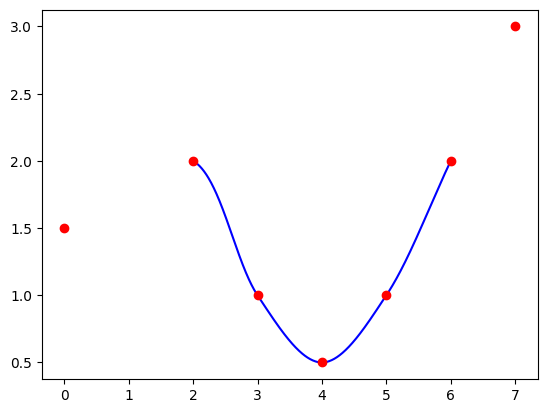

In [5]:
POINTS: tuple = ((0, 1.5), (2, 2), (3, 1), (4, 0.5), (5, 1), (6, 2), (7, 3))  # Red points
NUM_POINTS: int = 100  # Density of blue chain points between two red points

chain_points: list = catmull_rom_chain(POINTS, NUM_POINTS)
assert len(chain_points) == num_segments(POINTS) * NUM_POINTS  # 400 blue points for this example

plt.plot(*zip(*chain_points), c="blue")
plt.plot(*zip(*POINTS), c="red", linestyle="none", marker="o")
plt.show()

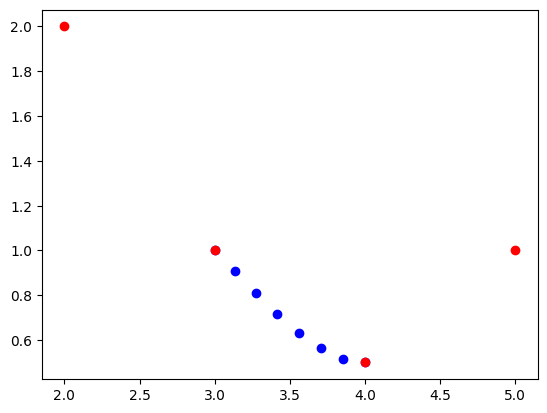

In [6]:

control_points = POINTS[1:5]

plt.scatter(*zip(*catmull_rom_spline(*control_points, 8, alpha=1.0)), c="blue")
plt.scatter(*zip(*control_points), c="red", marker="o")

t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847
t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847


C:\Users\user\AppData\Local\Temp\ipykernel_17264\436928162.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(*zip(*point), c=cmap(t * 2.0 if t < 0.5 else (1.0 - t) * 2.0), marker="o")


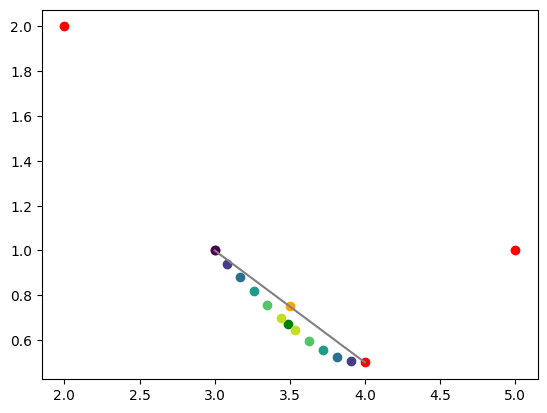

In [7]:


midpoint = (numpy.array(control_points[2]) + numpy.array(control_points[1])) / 2
plt.plot(*zip(*control_points[1:3]), c="grey")
plt.scatter(*zip(*[midpoint]), c="orange", marker="o")
plt.scatter(*zip(*control_points), c="red", marker="o")
plt.scatter(*zip(*catmull_rom_spline_point(*control_points, 0.5, alpha=1.0)), c="green")
cmap = plt.get_cmap("viridis")
for i in range(11):
    t = i / 11
    point = catmull_rom_spline_point(*control_points, t, alpha=1.0)
    plt.scatter(*zip(*point), c=cmap(t * 2.0 if t < 0.5 else (1.0 - t) * 2.0), marker="o")

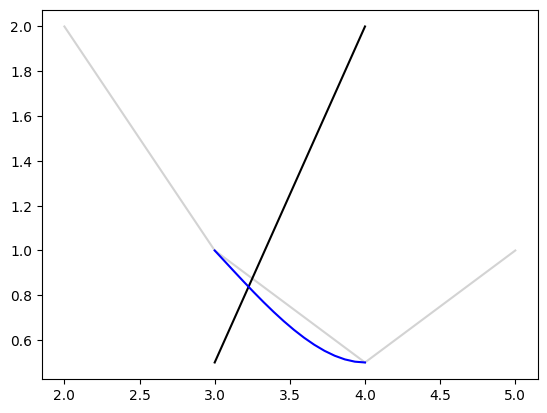

In [8]:
plt.plot(*zip(*control_points), c="lightgrey")
some_line = [(3, .5), (4, 2)]
plt.plot(*zip(*some_line), c="black")
chain_points: list = catmull_rom_chain(control_points, 16)
plt.plot(*zip(*chain_points), c="blue")


In [9]:
coefficients = catmull_rom_coefficients(*control_points, alpha=1.0)
coefficients

(array([-0.11696312,  0.33772234]),
 array([ 0.23392624, -0.17544468]),
 array([ 0.88303688, -0.66227766]),
 array([3., 1.]))

In [10]:
intersection = intersect_catmull_rom_spline(coefficients, *some_line)

a: 0.5131670194948625
, b: -0.5263340389897248
, c: -1.986832980505138
, d: 0.5



t0, t1, t2, t3 0.0 1.4142135623730951 2.53224755112299 3.6502815398728847


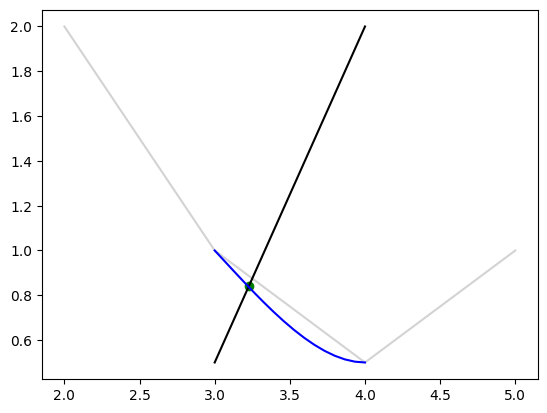

In [11]:
plt.plot(*zip(*control_points), c="lightgrey")
some_line = [(3, .5), (4, 2)]
plt.plot(*zip(*some_line), c="black")
chain_points: list = catmull_rom_chain(control_points, 16)
plt.plot(*zip(*chain_points), c="blue")
intersection_points = [catmull_rom_spline_point(*control_points, t_i, alpha=1.0) for t_i in intersection if 1.0 >= t_i >= 0.0]
intersection_points
for point in intersection_points:
    plt.scatter(*zip(*point), c="green", marker="o")

In [12]:
def cint(points: numpy.ndarray, u: float):
    # We get 4 points as a 4xd array
    u_sq = u * u
    u_cub = u_sq * u

    U = 0.5 * numpy.array([[
        -u_cub + 2 * u_sq - u,
        3 * u_cub - 5 * u_sq + 2,
        -3 * u_cub + 4 * u_sq + u,
        u_cub - u_sq,
    ]])
    return U.T * points

cint(numpy.array(control_points), 0.2)


array([[-0.128, -0.128],
       [ 2.736,  0.912],
       [ 0.672,  0.084],
       [-0.08 , -0.016]])

# 3D Catmull Rom spline intersections

In [57]:
def catmull_rom_spline_point(
    P0: numpy.ndarray,
    P1: numpy.ndarray,
    P2: numpy.ndarray,
    P3: numpy.ndarray,
    t: float,
    alpha: float = 0.5,
) -> tuple:

    assert 1.0 >= t >= 0.0, "t must be between 0 and 1"
    def tj(ti: float, pi: numpy.ndarray, pj: numpy.ndarray) -> float:
        d = pi - pj
        l = numpy.linalg.norm(d)
        return ti + l ** alpha
    
    t0: float = 0.0
    t1: float = tj(t0, P0, P1)
    t2: float = tj(t1, P1, P2)
    t3: float = tj(t2, P2, P3)
    print("t0, t1, t2, t3", t0, t1, t2, t3)
    t = t * (t2 - t1) + t1
    t = numpy.array([[t]])
    A1 = (t1 - t) / (t1 - t0) * P0 + (t - t0) / (t1 - t0) * P1
    A2 = (t2 - t) / (t2 - t1) * P1 + (t - t1) / (t2 - t1) * P2
    A3 = (t3 - t) / (t3 - t2) * P2 + (t - t2) / (t3 - t2) * P3
    B1 = (t2 - t) / (t2 - t0) * A1 + (t - t0) / (t2 - t0) * A2
    B2 = (t3 - t) / (t3 - t1) * A2 + (t - t1) / (t3 - t1) * A3
    point = (t2 - t) / (t2 - t1) * B1 + (t - t1) / (t2 - t1) * B2
    return point


def catmull_rom_coefficients(P0, P1, P2, P3, alpha=0.5):
    """
    Compute the 2D cubic polynomial coefficients (A, B, C, D)
    for the Catmull–Rom spline segment between P1 and P2.
    
    P0, P1, P2, P3: Tuple or list of two floats (x, y).
    alpha: Controls the tension (0.5 is centripetal, 1.0 is chordal).
    
    Returns:
        A, B, C, D : Each a 2D numpy array representing the coefficients
                     such that P(u) = A*u^3 + B*u^2 + C*u + D, u in [0, 1].
    """
    # Convert points to numpy arrays
    P0 = numpy.array(P0, dtype=float)
    P1 = numpy.array(P1, dtype=float)
    P2 = numpy.array(P2, dtype=float)
    P3 = numpy.array(P3, dtype=float)
    
    def tj(ti, pi, pj):
        return ti + numpy.linalg.norm(pj - pi) ** alpha
    
    # Compute t-values based on chord lengths
    t0 = 0.0
    t1 = tj(t0, P0, P1)
    t2 = tj(t1, P1, P2)
    t3 = tj(t2, P2, P3)

    
    # Compute tangent vectors for the Hermite representation
    m1 = (t2 - t1) / (t2 - t0) * (P2 - P0)
    m2 = (t2 - t1) / (t3 - t1) * (P3 - P1)
    
    # Convert the Hermite form to the polynomial form
    # Using the known relationships:
    # D = P1
    # C = m1
    # B = -3P1 + 3P2 - 2m1 - m2
    # A = 2P1 - 2P2 + m1 + m2
    D_coef = P1
    C_coef = m1
    B_coef = -3 * P1 + 3 * P2 - 2 * m1 - m2
    A_coef = 2 * P1 - 2 * P2 + m1 + m2
    
    return A_coef, B_coef, C_coef, D_coef

def intersect_catmull_rom_spline(coeffs, boundary):
    """
    Find the u-values in [0,1] where the 2D cubic spline defined by the coefficients
    intersects the line passing through points L0 and L1.
    
    coeffs: Tuple (A, B, C, D) as returned by catmull_rom_coefficients.
    boundary: in the 2d case a line defined by two points L0 and L1. In the 3d case an origin and 2 direction vectors.
    tol_imag: Tolerance to filter out complex roots.
    
    Returns:
        A list of parameter values u (in [0,1]) at which the spline intersects the line.
    """
    A, B, C, D = coeffs

    
    # Compute a normal for the line.
    # 2d case
    if boundary.shape[0] == 2 and boundary.shape[0] == 2:
        L0 = numpy.array(boundary, dtype=float)
        L1 = numpy.array(boundary, dtype=float)
        d = L1 - L0
        # Choose a normal (here, perpendicular: (-dy, dx))
        n = numpy.array([-d[1], d[0]])
        # Compute the constant in the line's implicit equation
        d = -numpy.dot(n, L0)
    # 3d case
    elif boundary.shape[0] == 3 and boundary.shape[0] == 3:
        U = numpy.array(boundary[1], dtype=float)
        V = numpy.array(boundary[2], dtype=float)
        P0 = numpy.array(boundary[0], dtype=float)
        n = numpy.cross(U, V)
        d = numpy.dot(-n, P0)

    else:
        raise ValueError("L0 and L1 must be 2D or 3D points.")
    
    # The intersection condition: n · (A*u^3 + B*u^2 + C*u + D) + d_line = 0.
    # This is a cubic polynomial in u:
    a_poly = numpy.dot(n, A)
    b_poly = numpy.dot(n, B)
    c_poly = numpy.dot(n, C)
    d_poly = numpy.dot(n, D) + d
    
    # Solve the cubic equation a*u^3 + b*u^2 + c*u + d_poly = 0
    poly_coeffs = [a_poly, b_poly, c_poly, d_poly]
    roots = solve_cubic(*poly_coeffs)
    return roots

def recover_intersection_point(control_points, roots: list[float], boundary):
    intersection_points = [catmull_rom_spline_point(*control_points, t=r, alpha=1.0) for r in roots if 0 <= r <= 1]
    P0 = boundary[0]
    U = boundary[1]
    V = boundary[2]
    G = numpy.array([[numpy.dot(U, U), numpy.dot(U, V)], [numpy.dot(V, U), numpy.dot(V, V)]], dtype=float)
    det_G = G[0, 0] * G[1, 1] - G[0, 1] * G[1, 0]
    G_inv = numpy.array([[G[1, 1], -G[0, 1]], [-G[1, 0], G[0, 0]]], dtype=float) / det_G
    ret = []
    for point in intersection_points:
        point = numpy.array(point, dtype=float)
        b = numpy.array([numpy.dot(U, U + V + P0), numpy.dot(V, U + V + P0)], dtype=float)
        ret.append(G_inv @ b)
    return ret
    

In [58]:
control_points = [(1.0, 0.4, 1.125), (0.5, 0.1, 0.0), (-1.0, 1.0, 0.0), (-1.0, -0.4, 0.7)]
u = numpy.array((1.0, 1.0, 0.0))
u /= numpy.linalg.norm(u)
v = numpy.array((-.5, 0.05, .35))
v /= numpy.linalg.norm(v)
intersection_plane = numpy.array([(-0.45, 0.5, -0.02), u, v])
coefficients = catmull_rom_coefficients(*control_points, alpha=1.0)
coefficients

(array([ 1.0485137 , -1.71592827, -0.28297803]),
 array([-1.38867081,  2.26797541,  0.93538965]),
 array([-1.15984288,  0.34795287, -0.65241162]),
 array([0.5, 0.1, 0. ]))

In [59]:
intersection_plane

array([[-0.45      ,  0.5       , -0.02      ],
       [ 0.70710678,  0.70710678,  0.        ],
       [-0.81649658,  0.08164966,  0.57154761]])

t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
t0, t1, t2, t3 0.0 1.2671

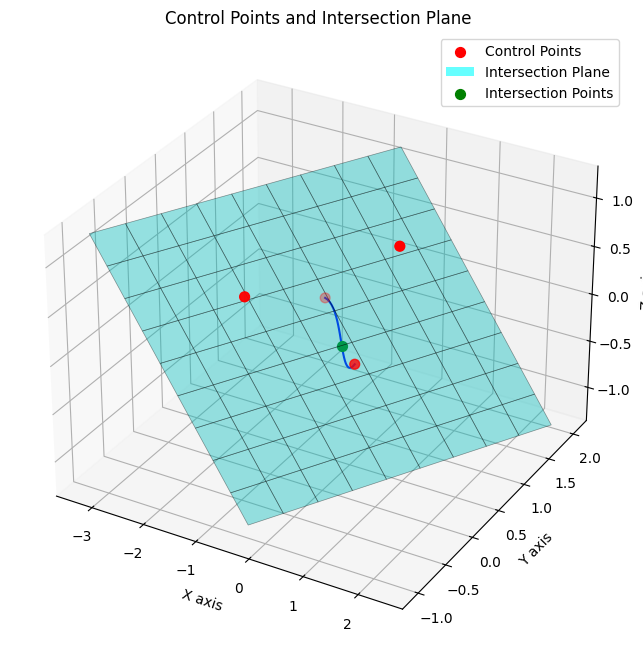

In [72]:
import numpy as np

control_points = numpy.array(control_points)
P0 = intersection_plane[0]
P1 = intersection_plane[1]
P2 = intersection_plane[2]

# Vectors lying in the plane, originating from P0
v1 = P1 / numpy.linalg.norm(P1)
v2 = P2 / numpy.linalg.norm(P2)

# --- Plotting Setup ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- Plot Control Points ---
ax.scatter(control_points[:, 0], control_points[:, 1], control_points[:, 2], c='r', marker='o', s=50, label='Control Points')

ax.scatter(i[0], i[1], i[2], c='g', marker='o', s=50, label='Intersection Points')

spline_points = [catmull_rom_spline_point(*control_points, t=r, alpha=1.0)[0] for r in np.linspace(0.0, 1.0, 24)]
# print(spline_points)
ax.plot(*zip(*spline_points), c='b', label='Spline Points')

# --- Plot the Line Segments ---
# ax.plot(*zip(*control_points), c='lightgrey', linewidth=2, label='Control Polygon')
# --- Plot Spline Points ---

# --- Plot the Plane using Parametric Equation ---
# Create a grid of parameter values (s, t)
# Adjust the range (-1.5 to 1.5 here) to control the size of the plotted plane patch
scale = 2.0
s_range = np.linspace(-scale, scale, 10)
t_range = np.linspace(-scale, scale, 10)
ss, tt = np.meshgrid(s_range, t_range)

# Calculate the corresponding X, Y, Z coordinates on the plane
# P(s, t) = P0 + s*v1 + t*v2
# We use np.outer to correctly combine the vectors with the meshgrid parameters
X = P0[0] + ss * v1[0] + tt * v2[0]
Y = P0[1] + ss * v1[1] + tt * v2[1]
Z = P0[2] + ss * v1[2] + tt * v2[2]

# Plot the plane surface
ax.plot_surface(X, Y, Z, alpha=0.4, color='cyan', edgecolor='k', linewidth=0.5, label='Intersection Plane')


# --- Plot Customization ---
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('Control Points and Intersection Plane')

# Determine plot limits based on control points and the generated plane patch
all_points = np.vstack([control_points, np.vstack([X.flatten(), Y.flatten(), Z.flatten()]).T])
min_vals = np.min(all_points, axis=0) - 0.2
max_vals = np.max(all_points, axis=0) + 0.2

ax.set_xlim(min_vals[0], max_vals[0])
ax.set_ylim(min_vals[1], max_vals[1])
ax.set_zlim(min_vals[2], max_vals[2])

# Add a legend
plane_proxy = plt.Rectangle((0, 0), 1, 1, fc="cyan", alpha=0.6) # Proxy artist for legend
ax.legend([ax.collections[0], plane_proxy, ax.collections[1]
           ], ['Control Points', 'Intersection Plane', 'Intersection Points'])

# Ensure equal aspect ratio (optional, can distort view)
# ax.set_aspect('equal')

plt.show()

In [61]:
normal = np.array([0.55, -0.44, 0.12]) - np.array([0.45, 0.5, 0.045])
normal = normal / np.linalg.norm(normal)
normal

array([ 0.10545467, -0.99127389,  0.079091  ])

In [62]:
roots = intersect_catmull_rom_spline(coefficients, intersection_plane)
roots

a: 0.9375207372640765
, b: -0.8837637637450193
, c: -1.0237054257576286
, d: 0.5582977103063682



[-0.9273302756062101, 0.4532842539565227, 1.4167065182314125]

In [65]:
boundary = intersection_plane

intersection_points = [catmull_rom_spline_point(*control_points, t=r, alpha=1.0) for r in roots if 0 <= r <= 1]
P0 = boundary[0]
U = boundary[1]
V = boundary[2]
G = numpy.array([[numpy.dot(U, U), numpy.dot(U, V)], [numpy.dot(V, U), numpy.dot(V, V)]], dtype=float)
det_G = G[0, 0] * G[1, 1] - G[0, 1] * G[1, 0]
G_inv = numpy.array([[G[1, 1], -G[0, 1]], [-G[1, 0], G[0, 0]]], dtype=float) / det_G
print(G_inv)
ret = []
for point in intersection_points:
    point = numpy.array(point, dtype=float)[0]
    print(f"point: {point}")
    X_ = point - P0
    b = numpy.array([numpy.dot(U, X_), numpy.dot(V, X_)], dtype=float)
    print(f"b: {b}")
    p_o = G_inv @ b
    print(f"uv: {p_o}")

t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861
[[1.36986301 0.7118017 ]
 [0.7118017  1.36986301]]
point: [-0.20523045  0.55081452 -0.16840502]
b: [ 0.2090095  -0.28052505]
uv: [ 0.08663618 -0.23550757]


In [71]:
i = p_o[0] * U + p_o[1] * V + P0

In [30]:
recover_intersection_point(control_points, roots, intersection_plane)

t0, t1, t2, t3 0.0 1.2671325897474186 3.0164181582010086 4.581665742450861


[array([0.92928932, 1.02071235])]

In [31]:
import numpy as np

points = np.array([[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.5, 1.0]])
ref = np.array([[0.5, 0.5, 0.1]])
points @ ref.T

array([[0.5 ],
       [0.5 ],
       [0.35]])

In [ ]:
dot_products = points @ ref.T
distances = np.abs(dot_products)

In [ ]:
min_dist = min(distances)
min_dist

array([0.35])

In [ ]:
mask = distances == min_dist
mask

array([[False],
       [False],
       [ True]])

In [ ]:
selects = mask * np.ceil(distances) * np.sign(dot_products)
selects

array([[0.],
       [0.],
       [1.]])

In [ ]:
unit = np.ones((1, 3)) / np.linalg.norm(selects)
(points * selects)

array([[0. , 0. , 0. ],
       [0. , 0. , 0. ],
       [1. , 1.5, 1. ]])